In [1]:
# Environment variables
import os
from dotenv import load_dotenv

# OpenAI models & embeddings / OLLAMA
from langchain_ollama import ChatOllama
from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Document loading & text processing
from pypdf import PdfReader
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embeddings & vector stores
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

# LangChain tools
from langchain_core.tools import tool

# LangGraph core
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Messages
from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage

# Typing
from typing import Annotated, TypedDict


In [2]:
load_dotenv()

# Disable LangSmith tracing
os.environ["LANGCHAIN_TRACING_V2"] = "false"

REASONING_MODEL = os.getenv("MODEL_NAME")
OLLAMA_MODEL_DEEPSEEK = os.getenv("OLLAMA_MODEL_DEEPSEEK")
OPENAI_MODEL_GEMMA3 = os.getenv("OPENAI_MODEL_GEMMA3")

OLLAMA_BASE_URL = os.getenv("OLLAMA_BASE_URL")
OPENAI_BASE_URL = os.getenv("OPENAI_BASE_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "ollama")

In [3]:
print("GEMMA:", OPENAI_MODEL_GEMMA3)
print("OLLAMA URL:", OLLAMA_BASE_URL)

GEMMA: gemma3:4b
OLLAMA URL: http://localhost:11434


In [4]:
# Initialize Ollama LLM
llm_ollama = ChatOllama(
    model=OPENAI_MODEL_GEMMA3,
    base_url=OLLAMA_BASE_URL,
    temperature=0.8,
)

llm_chat_openai = ChatOpenAI(
    base_url=OPENAI_BASE_URL,
    api_key=OPENAI_API_KEY,
    model=REASONING_MODEL,
    temperature=0.0,
)

# Initialize Ollama Base OpenAI LLM 
llm_openai = OpenAI(
    base_url=OPENAI_BASE_URL,
    api_key=OPENAI_API_KEY,
)


In [5]:
pdf_path = "data_and_files/Investment.pdf"
reader = PdfReader(pdf_path)

# Fetch only the important metadata
pdf_info = reader.metadata

important_info = {
    "source": pdf_path,
    "title": pdf_info.title,
    "author": pdf_info.author,
    "subject": pdf_info.subject,
    "creator": pdf_info.creator,
    "producer": pdf_info.producer,
    "creation_date": pdf_info.creation_date,
    "modification_date": pdf_info.modification_date,
    "pages": len(reader.pages)
}

print(important_info)


{'source': 'data_and_files/Investment.pdf', 'title': None, 'author': 'net_pc', 'subject': None, 'creator': 'Microsoft® Word 2019', 'producer': 'Microsoft® Word 2019', 'creation_date': datetime.datetime(2024, 1, 13, 5, 50, 5, tzinfo=datetime.timezone(datetime.timedelta(seconds=7200))), 'modification_date': datetime.datetime(2024, 1, 13, 5, 50, 5, tzinfo=datetime.timezone(datetime.timedelta(seconds=7200))), 'pages': 65}


In [6]:
# Load PDF and split into pages
data = "data_and_files\\Investment.pdf"
loader = PyPDFLoader(data)
pages = loader.load_and_split()

In [7]:
# pages

In [8]:
pages[0]

Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2024-01-13T05:50:05+02:00', 'author': 'net_pc', 'moddate': '2024-01-13T05:50:05+02:00', 'source': 'data_and_files\\Investment.pdf', 'total_pages': 65, 'page': 0, 'page_label': '1'}, page_content='1 | Page \nProf. Dr. Turgut Tursoy Investment \n \n \n \n \n \n \n \n \nInvestment \nProf. Dr. Turgut Tursoy \n \n \nIntro \n \nStart to understand that the in and waste would be \nfinding them together to create the new initiatives. It \nis the investment in life to understand a life that goes \nwith the extra efforts to gain the extra. Lots of life in a \nsimilar shape hopes to get more in life to improve. \nHall and the house would be waiting for the extra')

In [9]:
pages[0].metadata["source"]

'data_and_files\\Investment.pdf'

In [10]:
len(pages)

65

In [11]:
for doc in pages:
    print("Page:", doc.metadata["page"])
    print("Source:", doc.metadata["source"])
    print("Text preview:", doc.page_content[:2], "...\n")

Page: 0
Source: data_and_files\Investment.pdf
Text preview: 1  ...

Page: 1
Source: data_and_files\Investment.pdf
Text preview: 2  ...

Page: 2
Source: data_and_files\Investment.pdf
Text preview: 3  ...

Page: 3
Source: data_and_files\Investment.pdf
Text preview: 4  ...

Page: 4
Source: data_and_files\Investment.pdf
Text preview: 5  ...

Page: 5
Source: data_and_files\Investment.pdf
Text preview: 6  ...

Page: 6
Source: data_and_files\Investment.pdf
Text preview: 7  ...

Page: 7
Source: data_and_files\Investment.pdf
Text preview: 8  ...

Page: 8
Source: data_and_files\Investment.pdf
Text preview: 9  ...

Page: 9
Source: data_and_files\Investment.pdf
Text preview: 10 ...

Page: 10
Source: data_and_files\Investment.pdf
Text preview: 11 ...

Page: 11
Source: data_and_files\Investment.pdf
Text preview: 12 ...

Page: 12
Source: data_and_files\Investment.pdf
Text preview: 13 ...

Page: 13
Source: data_and_files\Investment.pdf
Text preview: 14 ...

Page: 14
Source: data_and_files\Investment.p

In [12]:
pages[0].metadata

{'producer': 'Microsoft® Word 2019',
 'creator': 'Microsoft® Word 2019',
 'creationdate': '2024-01-13T05:50:05+02:00',
 'author': 'net_pc',
 'moddate': '2024-01-13T05:50:05+02:00',
 'source': 'data_and_files\\Investment.pdf',
 'total_pages': 65,
 'page': 0,
 'page_label': '1'}

In [13]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
docs_chunks = splitter.split_documents(pages)

In [14]:
len(docs_chunks)

109

In [15]:
docs_chunks[0]

Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2024-01-13T05:50:05+02:00', 'author': 'net_pc', 'moddate': '2024-01-13T05:50:05+02:00', 'source': 'data_and_files\\Investment.pdf', 'total_pages': 65, 'page': 0, 'page_label': '1'}, page_content='1 | Page \nProf. Dr. Turgut Tursoy Investment \n \n \n \n \n \n \n \n \nInvestment \nProf. Dr. Turgut Tursoy \n \n \nIntro \n \nStart to understand that the in and waste would be \nfinding them together to create the new initiatives. It \nis the investment in life to understand a life that goes \nwith the extra efforts to gain the extra. Lots of life in a \nsimilar shape hopes to get more in life to improve. \nHall and the house would be waiting for the extra')

In [16]:
print(docs_chunks[0].page_content[:100])

1 | Page 
Prof. Dr. Turgut Tursoy Investment 
 
 
 
 
 
 
 
 
Investment 
Prof. Dr. Turgut Tursoy 
 


In [17]:
print(docs_chunks[0].metadata)

{'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2024-01-13T05:50:05+02:00', 'author': 'net_pc', 'moddate': '2024-01-13T05:50:05+02:00', 'source': 'data_and_files\\Investment.pdf', 'total_pages': 65, 'page': 0, 'page_label': '1'}


In [18]:
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
vectorstore = FAISS.from_documents(docs_chunks, embeddings)

In [19]:
# number of vectors 
vectorstore.index.ntotal

109

In [20]:
# vector dimension
vectorstore.index.d

384

In [21]:
# number of documents
len(vectorstore.docstore._dict)

109

In [22]:
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k":3})

In [23]:
docs = retriever.invoke("How to Invest?")
for doc in docs:
    print("Content: ", doc.page_content)
    print("Metadata: ", doc.metadata)  

Content:  best practices. It should also seek professional advice 
if it is are unsure about investing or need help creating 
and managing an investment plan.
Metadata:  {'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2024-01-13T05:50:05+02:00', 'author': 'net_pc', 'moddate': '2024-01-13T05:50:05+02:00', 'source': 'data_and_files\\Investment.pdf', 'total_pages': 65, 'page': 8, 'page_label': '9'}
Content:  5 | Page 
Prof. Dr. Turgut Tursoy Investment 
2. Fundamentals of investment 
 
Investing is allocating money to an asset with the 
expected earning  income or capital appreciation in 
the future. Investing can help achiev e various 
financial goals : saving, superannuation, buying a 
home, or funding a child's education. Investing can 
also help you diversify your income streams, protect 
your wealth from inflation, and take advantage of tax 
benefits. Different instrument types include  stocks, 
bonds, mutual funds, real estate, commodities, a

In [24]:
len(docs)

3

In [25]:
docs[0].page_content

'best practices. It should also seek professional advice \nif it is are unsure about investing or need help creating \nand managing an investment plan.'

In [26]:
docs[1].page_content

"5 | Page \nProf. Dr. Turgut Tursoy Investment \n2. Fundamentals of investment \n \nInvesting is allocating money to an asset with the \nexpected earning  income or capital appreciation in \nthe future. Investing can help achiev e various \nfinancial goals : saving, superannuation, buying a \nhome, or funding a child's education. Investing can \nalso help you diversify your income streams, protect \nyour wealth from inflation, and take advantage of tax \nbenefits. Different instrument types include  stocks, \nbonds, mutual funds, real estate, commodities, and \ncryptocurrencies. Each type has its risk-return profile, \nliquidity, and suitability for different investors. Before \ninvesting, it should assess risk tolerance, time \nhorizon, and financial objectives. It should also \nresearch the potential returns, costs, and risks of any \ninvestment are considering. Investing is discipline \nand a long -term perspective. It should not invest \nmoney it cannot afford to lose or  need in t

In [27]:
docs[2].page_content

'money it cannot afford to lose or  need in the short \nterm. It should also diversify its portfolio to reduce \nexposure to any  asset or market. Investing can be \nrewarding and enjoyable if it follows basic principles \nand best practices. It should also seek prof essional \nadvice if it is  unsure about any investing aspect or'

In [43]:
@tool
def retrieve_documents(query: str) -> dict:
    """
    Retrieve relevant information from PDF documents.

    Returns a dictionary with the query, combined content, and metadata.
    """
    docs = retriever.invoke(query)

    combined_content = "\n\n".join(doc.page_content for doc in docs)
    metadata = [doc.metadata for doc in docs]

    return {
        'query': query,
        'combined_content': combined_content,
        'metadata': metadata
    }

In [59]:
tools = [retrieve_documents]
llm_with_tools = llm_chat_openai.bind_tools(tools)

In [60]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [61]:
def chat_node(state: ChatState) -> ChatState:
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    tool_output = getattr(response, "tool_output", None)
    return {
        "messages": [response],
        "tool_output": tool_output,
        "debug_chat_node_output": response
    }

In [62]:
tool_node_retrieve = ToolNode(tools)

In [63]:
def tool_node_with_debug(*args, **kwargs):
    output = tool_node_retrieve.invoke(*args, **kwargs)
    print("ToolNode output:", output)
    return output

In [64]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node_with_debug)  # debug version for each node what output is
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

rag_chatbot = graph.compile()

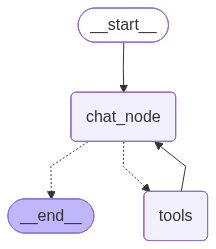

In [65]:
rag_chatbot

In [66]:
# SYSTEM_PROMPT = """You are an expert economics tutor. Provide clear, concise, and detailed explanations for any economics concept or model. 
# If a user asks about a topic that requires referencing documents, use the document retrieval tool."""

In [67]:
SYSTEM_PROMPT = """
You are an expert economics tutor. Answer the user question ONLY using the documents provided.
Do not use your own knowledge. If the documents do not contain the answer, respond: 
'I could not find an answer in the documents.'
Always reference the document content in your answer.
"""

In [68]:
# openai_response = rag_chatbot.chat.completions.create(
#     model=REASONING_MODEL,
#     messages=[
#         {"role": "system", "content": SYSTEM_PROMPT},
#         {"role": "user", "content": 'Explain what is Micro-economic models?'}
#     ]
# )

In [69]:
result = rag_chatbot.invoke(
    {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content="Explain what is Micro-economic models?")
        ]
    }
)

ToolNode output: {'messages': [ToolMessage(content='{"query": "micro-economic models", "combined_content": "62 | Page \\nProf. Dr. Turgut Tursoy Investment \\nused to evaluate the impact of fiscal and monetary \\npolicies on macroeconomic indicators and outcomes. \\n \\n- Sectoral models: These models focus on specific \\nsectors or industries in the economy, such as \\nagriculture, energy, health, and education. Sectoral \\nmodels can be used to assess the impact of sector -\\nspecific policies or regulations on sectoral \\nperformance and outcomes. \\n \\n- Micro-economic models: These models analyze the \\nbehaviour and decisions of economic agents, such as \\nhouseholds, firms, consumers, and producers. Micro-\\neconomic models can be used to examine the impact \\nof policies or interventions on distributional issues, \\nsuch as income inequality, poverty, and welfare. \\n \\nFinancial modelling can provide valuable \\npolicymaking insights but  has some limitations and \\nchalleng

In [84]:
result

{'messages': [SystemMessage(content="\nYou are an expert economics tutor. Answer the user question ONLY using the documents provided.\nDo not use your own knowledge. If the documents do not contain the answer, respond: \n'I could not find an answer in the documents.'\nAlways reference the document content in your answer.\n", additional_kwargs={}, response_metadata={}, id='42b8c03c-09e6-431d-9b89-99414d1ebc06'),
  HumanMessage(content='Explain what is Micro-economic models?', additional_kwargs={}, response_metadata={}, id='3ab1cf03-d317-4889-8ec2-a57441207214'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 253, 'prompt_tokens': 214, 'total_tokens': 467, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen3:latest', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-251', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b83c4-3a46-76f1-b664

In [70]:
print("Chat node messages:", result['messages'][-1].content)

Chat node messages: Micro-economic models are analytical tools that focus on the behavior and decision-making processes of individual economic agents, such as households, firms, consumers, and producers. These models examine how policies or interventions influence distributional outcomes, including issues like income inequality, poverty, and welfare. They provide insights into the interactions between economic agents and how their choices impact resource allocation, market dynamics, and societal welfare. The document highlights their role in assessing the effects of policies on distributional issues, emphasizing their application in understanding complex economic phenomena through mathematical equations and simulations.


In [88]:
last_msg = result['messages'][-1]
last_msg

AIMessage(content='Micro-economic models are analytical tools that focus on the behavior and decision-making processes of individual economic agents, such as households, firms, consumers, and producers. These models examine how policies or interventions influence distributional outcomes, including issues like income inequality, poverty, and welfare. They provide insights into the interactions between economic agents and how their choices impact resource allocation, market dynamics, and societal welfare. The document highlights their role in assessing the effects of policies on distributional issues, emphasizing their application in understanding complex economic phenomena through mathematical equations and simulations.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 249, 'prompt_tokens': 983, 'total_tokens': 1232, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen3:latest', 's

In [90]:
if hasattr(last_msg, 'tool_calls'):
    print("Tool calls:", last_msg.tool_calls)

Tool calls: []


In [83]:
tool_data = result.get('tool_data')
if tool_data:
    print("Combined content:", tool_data['combined_content'])
    print("Metadata:", tool_data['metadata'])

In [76]:
# Get the ToolMessage from the ToolNode output
tool_msg = result['messages'][-1].additional_kwargs.get('tool_output', None)
print(tool_msg)

None


In [ ]:
# Access metadata
metadata = result['metadata']
print("Metadata: ", metadata)

In [ ]:
print("Combined content:\n", combined_content[:500], "...")  # just first 500 chars
print("\nMetadata:")
for m in metadata:
    print(m)

In [73]:
tool_output = result.get('tool_output', None)

In [74]:
if tool_output:
    print("\nTool was called!")
    print("Combined content from documents:")
    print(tool_output['combined_content'])
    print("\nMetadata:")
    print(tool_output['metadata'])
else:
    print("\nTool was NOT called.")


Tool was NOT called.


In [ ]:
result = rag_chatbot.invoke(
    {
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content="What is the concept of rational expectation in economics, and what are its key implications for agents’ behavior?")
        ]
    }
)

In [55]:
print("Model output:")
print(result['messages'][-1].content)

Model output:
The concept of **rational expectation** in economics, as described in the documents, assumes that agents form their expectations about the future by using all available information and the structure of the economic model. These expectations are **consistent with actual outcomes** and imply that agents do not make **systematic errors** in forecasting. Additionally, agents **learn from past forecasting errors** and update their expectations accordingly. 

### Key Implications for Agents’ Behavior:
1. **Consistency with Equilibrium Outcomes**: Agents’ expectations align with the equilibrium outcomes of the economic model. Once expectations are formed, there is **no incentive for agents to change their plans**, as their forecasts are already consistent with the model’s predictions.  
2. **Policy Responses**: Rational expectations are critical in analyzing how agents respond to changes in economic policies (e.g., monetary or fiscal policy). For example, if agents anticipate a 

In [56]:
tool_output = result.get('tool_output', None)

In [57]:
if tool_output:
    print("\nTool was called!")
    print("Combined content from documents:")
    print(tool_output['combined_content'])
    print("\nMetadata:")
    print(tool_output['metadata'])
else:
    print("\nTool was NOT called.")


Tool was NOT called.


In [ ]:
tools_condition_output = tools_condition(result)
print("tools_condition output:", tools_condition_output)

tools_condition output: __end__
